# Pre processing

## Unity Partial scan + Pano to trimesh coordinates

In [1]:
import os
import sys
sys.path.insert(0, '../')
import drm
import numpy as np
from PIL import Image

### Pcd Conversion

In [2]:
# Convert the txt to a correctly oriented bin file for votenet and further processing
txtPath = "/home/jvermandere/projects/DRM/_input/Office2.txt"
pano_file = "/home/jvermandere/projects/DRM/_input/Office2.png"
# Create the bin pointcloud file, with converted coordinates: (x,y,z) -> (x,z,y)
binPath = drm.txt_pcd_to_bin(txtPath, rotateX=True, containsNormals=True, mirrorY=True)

# Read the pointcloud from the bin file
points = np.fromfile(binPath, dtype=np.float32).reshape(-1, 6)  # x, y, z, rgb
print(points.shape)
# Extract positions and colors
xyz = points[:, :3]
rgb = points[:, 3:6]

Saved 77854 points to /home/jvermandere/projects/DRM/_input/Office2.bin
(77854, 6)


### TransformationMatrix from txt to file
Read the matrix from the pointcloud txt file and save it to a np file.

In [3]:
# --- Read transform matrix from the file ---
with open(txtPath, "r") as f:
    lines = f.readlines()

# Find the line that starts the matrix
matrix_start = None
for i, line in enumerate(lines):
    if line.startswith("# transform_matrix"):
        matrix_start = i + 1
        break
if matrix_start is None:
    raise ValueError("Transform matrix not found in file.")

# Read 4x4 matrix
transformationMartix = np.fromstring(lines[matrix_start][2:], dtype=float, sep=' ').reshape((4,4))
print(transformationMartix)
# The unity to trimesh coordinate system conversion matrix
unityToTrimeshT = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1]
], dtype=np.float32)
CorrectedTransformationMatrix =  unityToTrimeshT @ transformationMartix
print(CorrectedTransformationMatrix)

np.save(txtPath[:-4] + "_panomatrix.npy", CorrectedTransformationMatrix)



[[ 1.    0.    0.    0.48]
 [ 0.    1.    0.    2.54]
 [ 0.    0.    1.   -1.38]
 [ 0.    0.    0.    1.  ]]
[[ 1.    0.    0.    0.48]
 [ 0.    0.    1.   -1.38]
 [ 0.    1.    0.    2.54]
 [ 0.    0.    0.    1.  ]]


In [4]:
np.load("/home/jvermandere/projects/DRM/_input/Office2_panomatrix.npy")

array([[ 1.  ,  0.  ,  0.  ,  0.48],
       [ 0.  ,  0.  ,  1.  , -1.38],
       [ 0.  ,  1.  ,  0.  ,  2.54],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])

### Check the Pointcloud import

In [5]:
import trimesh
pcd = drm.load_bin_pointcloud(str(binPath))
scene = trimesh.Scene(pcd)
scene.add_geometry(trimesh.creation.axis(origin_size=0.05, axis_length=1.0, axis_radius=0.005))
axis = trimesh.creation.axis(origin_size=0.05, axis_length=1.0, axis_radius=0.005)
axis.apply_transform(CorrectedTransformationMatrix)
scene.add_geometry(axis)
scene.show()

### Check Pano alignment

In [6]:
import numpy as np

# Y rotation to align pano
Ry = np.array([
    [ 0, 0, -1, 0],
    [ 0, 1, 0, 0],
    [1, 0, 0, 0],
    [ 0, 0, 0, 1]
])
# Convert the pointcloud to uv coordinate space
uv_coords =  drm.transform_xyz_to_uv(xyz, Ry @ np.linalg.inv(CorrectedTransformationMatrix))

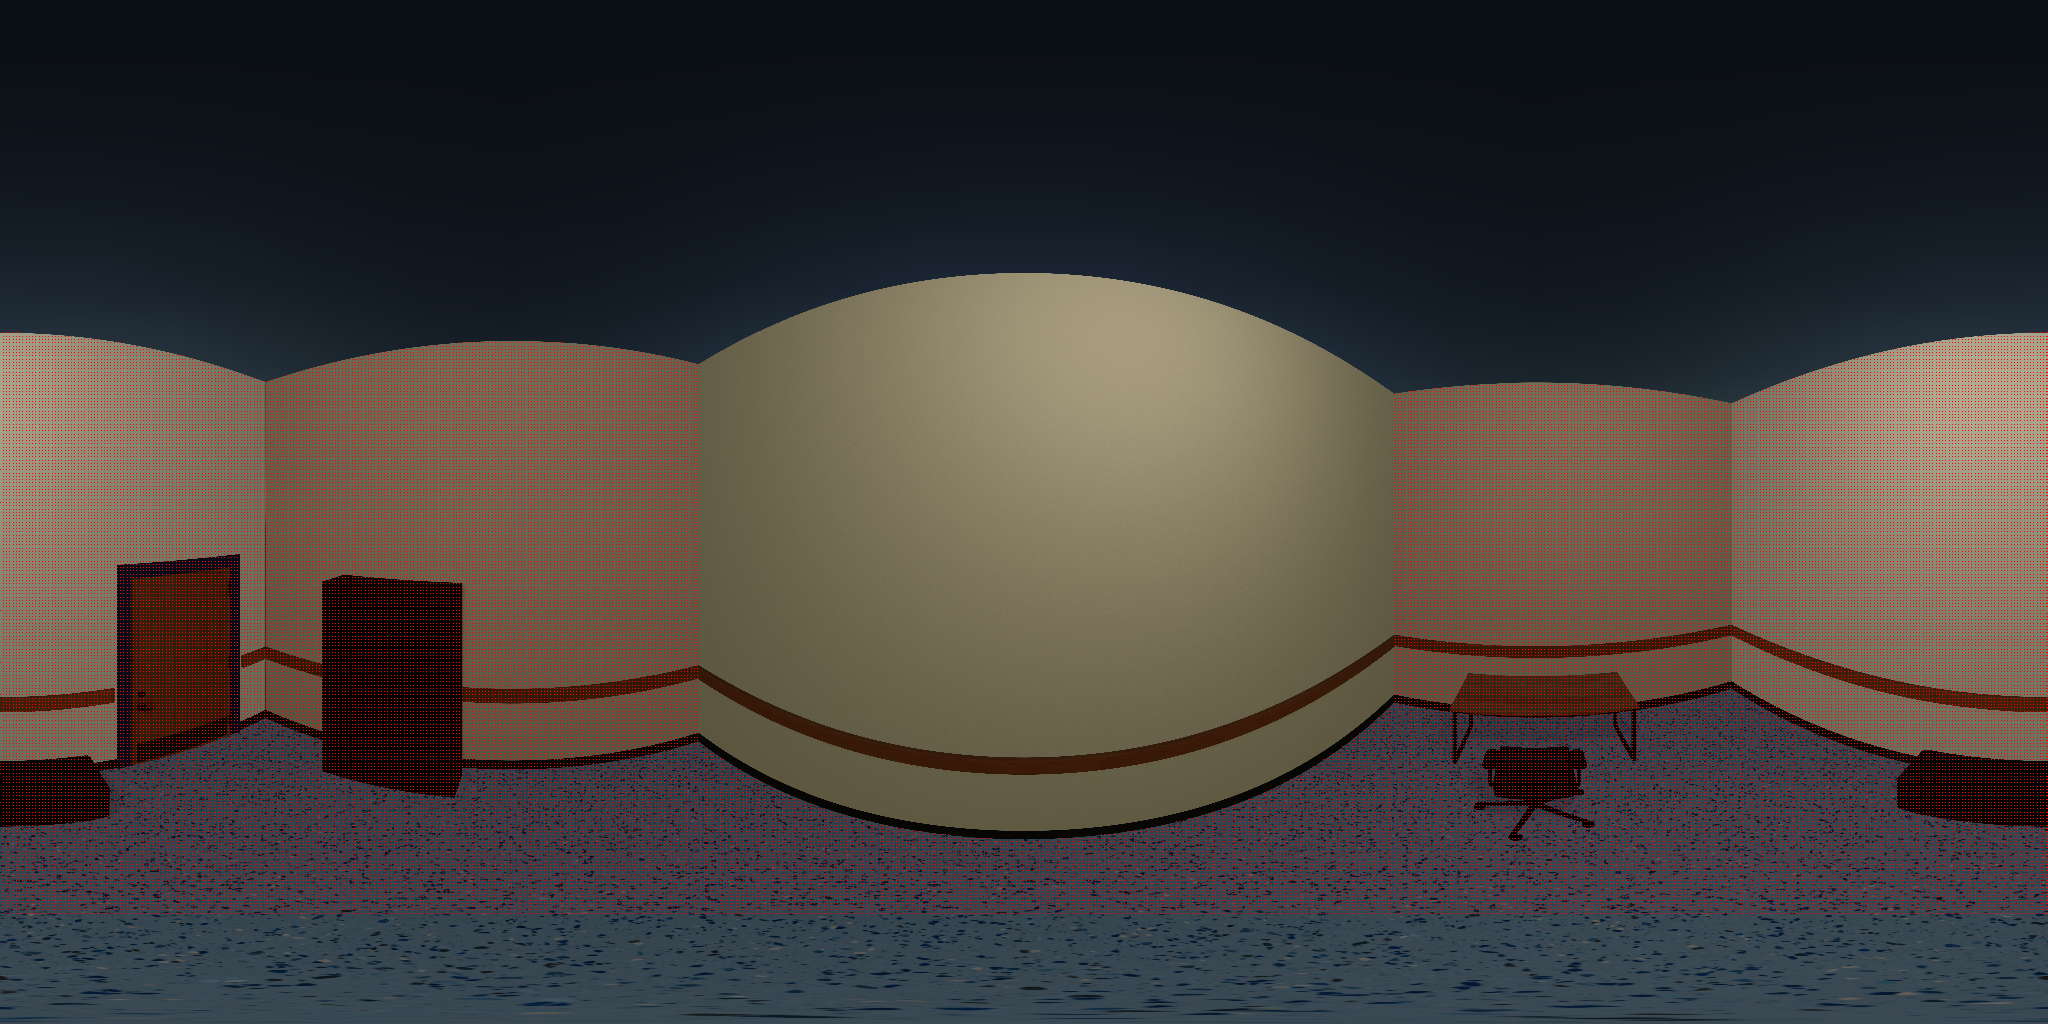

In [7]:
# --- Load equirectangular image ---
pano = Image.open(pano_file).convert("RGB")
width, height = pano.size
img = np.array(pano)

projectImage = img.copy()
for coord in uv_coords:
    u = int(coord[0] * width)
    v = int(coord[1] * height)
    #print(u,v)
    projectImage[min(v,height-1), min(u,width-1)] = [int(255), int(0), int(0)]
Image.fromarray(projectImage)

## Synthetic Dataset Preparation

In [ ]:
dataset_root_folder = r"/home/jvermandere/projects/DRM/_input/virtualDataset"

import os
from pathlib import Path
scanFolders = [p.as_posix() for p in  Path(dataset_root_folder).iterdir() if p.is_dir()]
print(scanFolders)

### Convert the files to bin and npy files for later processing

In [ ]:
import sys
sys.path.insert(0, '../')
import drm
import numpy as np

for folder in scanFolders:
    # Convert the txt to a correctly oriented bin file for votenet and further processing
    txtPath = os.path.join(folder, "main.txt")
    # Create the bin pointcloud file, with converted coordinates: (x,y,z) -> (x,z,y)
    binPath = drm.txt_pcd_to_bin(txtPath, rotateX=True, containsNormals=True, mirrorY=True)
    #Also convert the empty scene
    drm.txt_pcd_to_bin(txtPath[:-4] + "_empty.txt", rotateX=True, containsNormals=True, mirrorY=True)
    
    # Read transform matrix from the file
    with open(txtPath, "r") as f:
        lines = f.readlines()
    # Find the line that starts the matrix
    matrix_start = None
    for i, line in enumerate(lines):
        if line.startswith("# transform_matrix"):
            matrix_start = i + 1
            break
    if matrix_start is None:
        raise ValueError("Transform matrix not found in file.")
    # Read 4x4 matrix
    transformationMartix = np.fromstring(lines[matrix_start][2:], dtype=float, sep=' ').reshape((4,4))
    print(transformationMartix)
    # The unity to trimesh coordinate system conversion matrix
    CorrectedTransformationMatrix =  drm.UNITY2TRIMESH_T @ transformationMartix
    print(CorrectedTransformationMatrix)
    np.save(txtPath[:-4] + "_panomatrix.npy", CorrectedTransformationMatrix)